# Child Glint Data Preprocessing Notebook

## Novel Glint 

### Read in the data

In [1]:
%reset -f
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Load your data
df = pd.read_csv("/zpool/vladlab/data_drive/child_glint_data/child_glint/novel_glint/results/Abracadabra--This-is-new-_all-responses-identifiable_novel_official_03_24_26.csv"
) # Fill in the path to your CSV file



### Group data by Condition 

In [2]:
# 1) Keep only the categories we care about
categories = ['mask', 'scram', 'nat', 'prac']
df = df[df['image_category'].isin(categories)].copy()

# 1b) Rename categories for plotting
rename_map = {
    'prac': 'Practice',
    'nat': 'Natural',
    'scram': 'Feature',
    'mask': 'Shape'
}

# Rename the categories in the original dataframe for consistency in plotting
df['image_category'] = df['image_category'].map(rename_map)


# 2) Compute accuracy per child per category
sub_summary = (
    df.groupby(['child_hashid', 'image_category'], as_index=False)
      .agg(
          acc=('correct', 'mean'),
          n_trials=('correct', 'size')   # or 'count' if you want to ignore NaN in correct
      )
      .rename(columns={'image_category': 'condition', 'child_hashid': 'id'})

)

print(sub_summary)


         id condition       acc  n_trials
0    23XLLL  Practice  1.000000        12
1    2MRCNM   Feature  0.666667         9
2    2MRCNM   Natural  0.888889         9
3    2MRCNM  Practice  0.916667        12
4    2MRCNM     Shape  0.888889         9
..      ...       ...       ...       ...
208  ZPR3S2     Shape  0.444444         9
209  dWYd26   Feature  0.333333         9
210  dWYd26   Natural  0.888889         9
211  dWYd26  Practice  1.000000        12
212  dWYd26     Shape  0.777778         9

[213 rows x 4 columns]


### Exclusion Criteria 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CHANCE_LEVEL = 0.33

# Add any children you want to manually exclude here
MANUAL_EXCLUDE = ['23XLLL', 'ZCM6EU', 'BUJAAX']  

sub_summary_exclusion = sub_summary.copy()  # Create a copy to avoid modifying the original


# =========================
# NATURAL FILTER (if natural accuracy is at chance or 2SD below mean)
# =========================

#Create a separate DataFrame for natural condition to compute mean and SD, and apply filters
nat_acc = sub_summary_exclusion[sub_summary_exclusion['condition'] == 'Natural'][['id', 'acc']].copy() # Keep only child_hashid and acc for natural condition

# Compute mean and SD for natural condition
nat_mean = nat_acc['acc'].mean()
nat_std  = nat_acc['acc'].std(ddof=1)

# Compute 2SD cutoff
nat_cutoff = nat_mean - 2 * nat_std

# Flag children below chance and below 2SD cutoff for natural condition
nat_acc['nat_below_chance'] = nat_acc['acc'] < CHANCE_LEVEL # Flag children below chance level
nat_acc['nat_two_sd'] = nat_acc['acc'] < nat_cutoff # Flag children below 2SD cutoff

# =========================
# PRACTICE FILTER (if practice accuracy is at chance or 2SD below mean)
# =========================

# Create a separate DataFrame for practice condition to compute mean and SD, and apply filters
prac_acc = sub_summary_exclusion[sub_summary_exclusion['condition'] == 'Practice'][['id', 'acc']].copy()

# Compute mean and SD for practice condition
prac_mean = prac_acc['acc'].mean()
prac_std  = prac_acc['acc'].std(ddof=1)

# Compute 2SD cutoff
prac_cutoff = prac_mean - 2 * prac_std

# Flag children below chance and below 2SD cutoff for practice condition
prac_acc['prac_below_chance'] = prac_acc['acc'] < CHANCE_LEVEL # Flag children below chance level
prac_acc['prac_two_sd'] = prac_acc['acc'] < prac_cutoff # Flag children below 2SD cutoff


# =========================
# MERGE FILTERS
# =========================

# Merge the natural and practice filters on child_hashid, keeping all children (outer join)
filters = pd.merge(nat_acc[['id','nat_below_chance','nat_two_sd']],
                   prac_acc[['id','prac_below_chance','prac_two_sd']],
                   on='id',
                   how='outer').fillna(False)

# Add manual exclusion filter based on child_hashid 
filters['manual_excluded'] = filters['id'].isin(MANUAL_EXCLUDE)

# Remove if ANY criterion is true
filters['removed'] = (
    filters['nat_below_chance'] |
    filters['nat_two_sd'] |
    filters['prac_below_chance'] |
    filters['prac_two_sd'] |
    filters['manual_excluded']
)

# Print summary of filtering results
n_total = filters['id'].nunique() # Total unique children considered
n_removed = filters[filters['removed']]['id'].nunique() #  children removed
n_kept = filters[~filters['removed']]['id'].nunique() #  children kept

print("=== Combined Natural + Practice Filters ===")
print(f"Total children considered: {n_total}")
print(f"Children kept: {n_kept}")
print(f"Children removed: {n_removed}")
print()

print("Natural mean:", round(nat_mean,3), " | 2SD cutoff:", round(nat_cutoff,3))
print("Practice mean:", round(prac_mean,3), " | 2SD cutoff:", round(prac_cutoff,3))

# =========================
# KEEP CHILDREN
# =========================
kept_children = set(filters.loc[~filters['removed'], 'id'])
sub_summary_filt = sub_summary_exclusion[sub_summary_exclusion['id'].isin(kept_children)].copy()

=== Combined Natural + Practice Filters ===
Total children considered: 56
Children kept: 44
Children removed: 12

Natural mean: 0.624  | 2SD cutoff: 0.148
Practice mean: 0.837  | 2SD cutoff: 0.452


/tmp/ipykernel_2844785/1237563100.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  how='outer').fillna(False)


### Preliminary Stats and Plot (Just to see what data looks like and as a final check)

<Axes: xlabel='condition', ylabel='acc'>

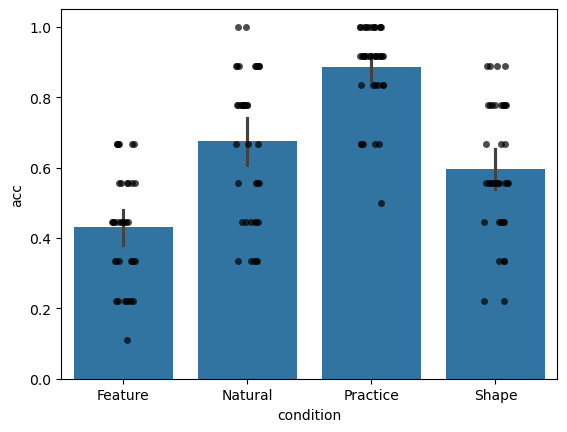

In [7]:
sns.barplot(data=sub_summary_filt, x='condition', y='acc')

sns.stripplot(data=sub_summary_filt, x='condition', y='acc', jitter=True, color='black', alpha=0.7)

### Convert to a wide format and Save the data 

In [4]:
import os
def create_wide_df_save_child(cleaned, output_path, file_stem="child_glint_novel"):
    """
    cleaned: long df with columns ['id', 'condition', 'acc', 'n_trials']
    """
    cleaned_wide = None
    if file_stem.endswith("novel"):
        print("Creating wide-format for novel data...")
        try:
            values = ["acc", "n_trials"]
                
            # Wide: one row per child, columns per condition for each metric
            pivot_df = cleaned.pivot_table(
                index="id",
                columns="condition",
                values=values,
                aggfunc="first"
            )

            # Flatten MultiIndex columns -> acc_Natural, n_trials_Natural, etc.
            pivot_df.columns = [f"{metric}_{cond}" for metric, cond in pivot_df.columns.to_flat_index()]
            pivot_df = pivot_df.reset_index()

            # Optional overall accuracy across available condition acc columns
            acc_cols = [c for c in pivot_df.columns if c.startswith("acc_")]
            pivot_df["acc_overall"] = pivot_df[acc_cols].mean(axis=1) if acc_cols else np.nan

            cleaned_wide = pivot_df

        except Exception as e:
            cleaned_wide = None
            print(f"Could not create wide-format: {e}")

    elif file_stem.endswith("familiar"):

        try:
            values = ["acc", "n_trials"]

            # Wide: one row per child, columns per condition for each metric
            pivot_df = cleaned.pivot_table(
                index="id",
                columns=["condition", "animacy"],  # Include animacy in columns for familiar data
                values=values,
                aggfunc="first"
            )

            # Flatten MultiIndex columns -> acc_Natural, n_trials_Natural, etc.
            pivot_df.columns = [f"{metric}_{cond}_{animacy}" for metric, cond, animacy in pivot_df.columns.to_flat_index()]
            pivot_df = pivot_df.reset_index()

            # Optional overall accuracy across available condition acc columns
            acc_cols = [c for c in pivot_df.columns if c.startswith("acc_")]
            pivot_df["acc_overall"] = pivot_df[acc_cols].mean(axis=1) if acc_cols else np.nan

            cleaned_wide = pivot_df

        except Exception as e:
            cleaned_wide = None
            print(f"Could not create wide-format: {e}")
    # Save long + wide
    long_csv = f"{file_stem}_cleaned_long.csv"
    cleaned.to_csv(os.path.join(output_path, long_csv), index=False)
    print(f"Saved long-format: {os.path.join(output_path, long_csv)}")

    if cleaned_wide is not None:
        wide_csv = f"{file_stem}_cleaned_wide.csv"
        cleaned_wide.to_csv(os.path.join(output_path, wide_csv), index=False)
        print(f"Saved wide-format: {os.path.join(output_path, wide_csv)}")

    return cleaned, cleaned_wide

In [5]:

sub_summary_long, sub_summary_wide = create_wide_df_save_child(cleaned=sub_summary_filt , output_path="/zpool/vladlab/data_drive/glint_master/data/child_data", file_stem="child_glint_novel")


Creating wide-format for novel data...
Saved long-format: /zpool/vladlab/data_drive/glint_master/data/child_data/child_glint_novel_cleaned_long.csv
Saved wide-format: /zpool/vladlab/data_drive/glint_master/data/child_data/child_glint_novel_cleaned_wide.csv


## Familiar Glint

### Load necessary packages and define the save and convert to wide df function

In [6]:
%reset -f
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

def create_wide_df_save_child(cleaned, output_path, file_stem="child_glint_novel"):
    """
    cleaned: long df with columns ['id', 'condition', 'acc', 'n_trials']
    """
    cleaned_wide = None
    try:
        values = ["acc", "n_trials"]
            
        # Wide: one row per child, columns per condition for each metric
        pivot_df = cleaned.pivot_table(
            index="id",
            columns="condition",
            values=values,
            aggfunc="first"
        )

        # Flatten MultiIndex columns -> acc_Natural, n_trials_Natural, etc.
        pivot_df.columns = [f"{metric}_{cond}" for metric, cond in pivot_df.columns.to_flat_index()]
        pivot_df = pivot_df.reset_index()

        # Optional overall accuracy across available condition acc columns
        acc_cols = [c for c in pivot_df.columns if c.startswith("acc_")]
        pivot_df["acc_overall"] = pivot_df[acc_cols].mean(axis=1) if acc_cols else np.nan

        cleaned_wide = pivot_df

    except Exception as e:
        cleaned_wide = None
        print(f"Could not create wide-format: {e}")
            # Save long + wide
    long_csv = f"{file_stem}_cleaned_long.csv"
    cleaned.to_csv(os.path.join(output_path, long_csv), index=False)
    print(f"Saved long-format: {os.path.join(output_path, long_csv)}")

    if cleaned_wide is not None:
        wide_csv = f"{file_stem}_cleaned_wide.csv"
        cleaned_wide.to_csv(os.path.join(output_path, wide_csv), index=False)
        print(f"Saved wide-format: {os.path.join(output_path, wide_csv)}")

    return cleaned, cleaned_wide



## Load the Data

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Load your data
df = pd.read_csv(
    "/zpool/vladlab/data_drive/child_glint_data/child_glint/familiar_glint/results/Abracadabra--What-is-this-now-_all-responses-identifiable_familiar_official_5yo_03_24_26.csv"
)
#Rename the missing values in image_category to 'prac' for practice trials, then map all categories to their new names for plotting
df["image_category"] = df["image_category"].fillna("prac")

#Rename animacy categories, filling missing values with 'Practice'
df['object_category'] = df['object_category'].fillna('Practice')

print(df.head())

                             study_uuid participant_hashid child_hashid  \
0  0ded2ba3-f427-48c1-b597-0f231f16dc7f             MEG2Rd       UXVHLG   
1  0ded2ba3-f427-48c1-b597-0f231f16dc7f             MEG2Rd       UXVHLG   
2  0ded2ba3-f427-48c1-b597-0f231f16dc7f             MEG2Rd       UXVHLG   
3  0ded2ba3-f427-48c1-b597-0f231f16dc7f             MEG2Rd       UXVHLG   
4  0ded2ba3-f427-48c1-b597-0f231f16dc7f             MEG2Rd       UXVHLG   

                    child_age  trial_index trial_type     target_image  \
0  5 years, 2 months, 19 days            1   practice  bicycle(1).JPEG   
1  5 years, 2 months, 19 days            2   practice      dog(1).JPEG   
2  5 years, 2 months, 19 days            3   practice     duck(2).JPEG   
3  5 years, 2 months, 19 days            4   practice    tree(10).JPEG   
4  5 years, 2 months, 19 days            5   practice    truck(1).JPEG   

  image_category object_class object_category         left_word  \
0           prac      bicycle        

### Group data by Condition

In [8]:
# 1) Keep only the categories we care about
categories = ['mask', 'scram', 'crop', 'prac']
df = df[df['image_category'].isin(categories)].copy()

# 1b) Rename categories for plotting
rename_map = {
    'prac': 'Practice',
    'crop': 'Natural',
    'scram': 'Feature',
    'mask': 'Shape'
}

df['image_category'] = df['image_category'].map(rename_map)

# 2) Compute accuracy per child per category

sub_summary = (
    df.groupby(['child_hashid', 'image_category'], as_index=False)
      .agg(
          acc=('correct', 'mean'),
          n_trials=('correct', 'size')   # or 'count' if you want to ignore NaN in correct
      )
      .rename(columns={'image_category': 'condition', 'child_hashid': 'id', 'object_category': 'animacy'})
    
)

print(sub_summary.head())

       id condition       acc  n_trials
0  2dEUY7   Feature  0.916667        12
1  2dEUY7   Natural  0.916667        12
2  2dEUY7  Practice  1.000000         5
3  2dEUY7     Shape  0.583333        12
4  4G4YWP   Feature  0.583333        12


### (if you want animacy included, run this block)

In [ ]:
# 1) Keep only the categories we care about
categories = ['mask', 'scram', 'crop', 'prac']
df = df[df['image_category'].isin(categories)].copy()

# 1b) Rename categories for plotting
rename_map = {
    'prac': 'Practice',
    'crop': 'Natural',
    'scram': 'Feature',
    'mask': 'Shape'
}

df['image_category'] = df['image_category'].map(rename_map)

# 2) Compute accuracy per child per category

sub_summary = (
    df.groupby(['child_hashid', 'image_category', 'object_category'], as_index=False)
      .agg(
          acc=('correct', 'mean'),
          n_trials=('correct', 'size')   # or 'count' if you want to ignore NaN in correct
      )
      .rename(columns={'image_category': 'condition', 'child_hashid': 'id', 'object_category': 'animacy'})
    
)


### Exclusion Criteria 

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CHANCE_LEVEL = 0.5

# Add any children you want to manually exclude here
MANUAL_EXCLUDE = ["CQHS2B","7AF5NX"]  

sub_summary_exclusion = sub_summary.copy()  # Create a copy to avoid modifying the original


# =========================
# NATURAL FILTER (if natural accuracy is at chance or 2SD below mean)
# =========================

#Create a separate DataFrame for natural condition to compute mean and SD, and apply filters
nat_acc = sub_summary_exclusion[sub_summary_exclusion['condition'] == 'Natural'][['id', 'acc']].copy() # Keep only child_hashid and acc for natural condition

# Compute mean and SD for natural condition
nat_mean = nat_acc['acc'].mean()
nat_std  = nat_acc['acc'].std(ddof=1)

# Compute 2SD cutoff
nat_cutoff = nat_mean - 2 * nat_std

# Flag children below chance and below 2SD cutoff for natural condition
nat_acc['nat_below_chance'] = nat_acc['acc'] < CHANCE_LEVEL # Flag children below chance level
nat_acc['nat_two_sd'] = nat_acc['acc'] < nat_cutoff # Flag children below 2SD cutoff

# =========================
# PRACTICE FILTER (if practice accuracy is at chance or 2SD below mean)
# =========================

# Create a separate DataFrame for practice condition to compute mean and SD, and apply filters
prac_acc = sub_summary_exclusion[sub_summary_exclusion['condition'] == 'Practice'][['id', 'acc']].copy()

# Compute mean and SD for practice condition
prac_mean = prac_acc['acc'].mean()
prac_std  = prac_acc['acc'].std(ddof=1)

# Compute 2SD cutoff
prac_cutoff = prac_mean - 2 * prac_std

# Flag children below chance and below 2SD cutoff for practice condition
prac_acc['prac_below_chance'] = prac_acc['acc'] < CHANCE_LEVEL # Flag children below chance level
prac_acc['prac_two_sd'] = prac_acc['acc'] < prac_cutoff # Flag children below 2SD cutoff


# =========================
# MERGE FILTERS
# =========================

# Merge the natural and practice filters on child_hashid, keeping all children (outer join)
filters = pd.merge(nat_acc[['id','nat_below_chance','nat_two_sd']],
                   prac_acc[['id','prac_below_chance','prac_two_sd']],
                   on='id',
                   how='outer').fillna(False)

# Add manual exclusion filter based on child_hashid 
filters['manual_excluded'] = filters['id'].isin(MANUAL_EXCLUDE)

# Remove if ANY criterion is true
filters['removed'] = (
    filters['nat_below_chance'] |
    filters['nat_two_sd'] |
    filters['prac_below_chance'] |
    filters['prac_two_sd'] |
    filters['manual_excluded']
)

# Print summary of filtering results
n_total = filters['id'].nunique() # Total unique children considered
n_removed = filters[filters['removed']]['id'].nunique() #  children removed
n_kept = filters[~filters['removed']]['id'].nunique() #  children kept

print("=== Combined Natural + Practice Filters ===")
print(f"Total children considered: {n_total}")
print(f"Children kept: {n_kept}")
print(f"Children removed: {n_removed}")
print()

print("Natural mean:", round(nat_mean,3), " | 2SD cutoff:", round(nat_cutoff,3))
print("Practice mean:", round(prac_mean,3), " | 2SD cutoff:", round(prac_cutoff,3))

# =========================
# KEEP CHILDREN
# =========================
kept_children = set(filters.loc[~filters['removed'], 'id'])
sub_summary_filt = sub_summary_exclusion[sub_summary_exclusion['id'].isin(kept_children)].copy()

=== Combined Natural + Practice Filters ===
Total children considered: 40
Children kept: 35
Children removed: 5

Natural mean: 0.904  | 2SD cutoff: 0.731
Practice mean: 0.985  | 2SD cutoff: 0.878


/tmp/ipykernel_2844785/1291794389.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  how='outer').fillna(False)


<Axes: xlabel='condition', ylabel='acc'>

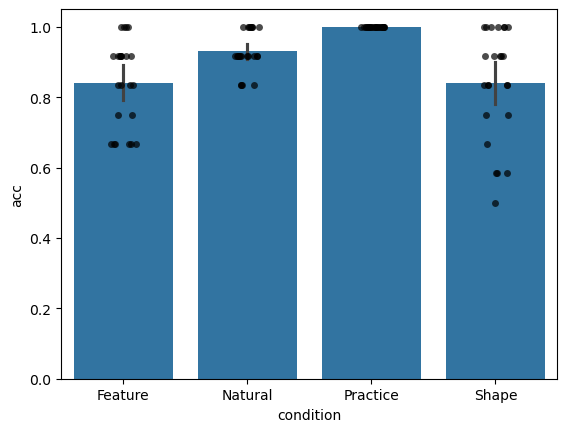

In [15]:
sns.barplot(data=sub_summary_filt, x='condition', y='acc')

sns.stripplot(data=sub_summary_filt, x='condition', y='acc', jitter=True, color='black', alpha=0.7)

In [16]:
stats = sub_summary_filt.groupby('condition')['acc'].agg(['mean', 'std', 'count']).reset_index()

### Convert to wide format and save

In [10]:

sub_summary_long, sub_summary_wide = create_wide_df_save_child(cleaned=sub_summary_filt , output_path="/zpool/vladlab/data_drive/glint_master/data/child_data", file_stem="child_glint_familiar")


Saved long-format: /zpool/vladlab/data_drive/glint_master/data/child_data/child_glint_familiar_cleaned_long.csv
Saved wide-format: /zpool/vladlab/data_drive/glint_master/data/child_data/child_glint_familiar_cleaned_wide.csv
